Elbow method is used to accurately predict the value of no of clusters (k) to be defined for KMeans clustering.

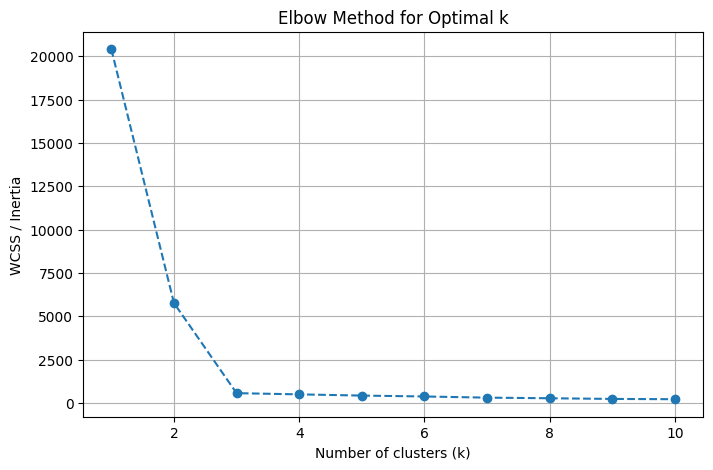

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs # Example data generation

# 1. Generate sample data (replace with your own dataset X)
X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

# List to store WCSS (inertia) values for each k
wcss = []

# 2. Run K-Means for a range of k values (e.g., 1 to 10)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=42, n_init=10)
    kmeans.fit(X)
    # The 'inertia_' attribute provides the WCSS value
    wcss.append(kmeans.inertia_)

# 3. Plot the WCSS values against the number of clusters
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.show()


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,_,random_state=42, test_size=0.2)
kmeans = KMeans(n_clusters=3, init="k-means++")
y_label = kmeans.fit_predict(X_train)
y_test_label = kmeans.predict(X_test)

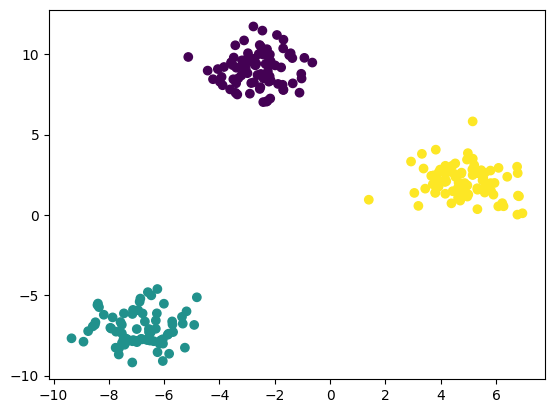

In [13]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_label)

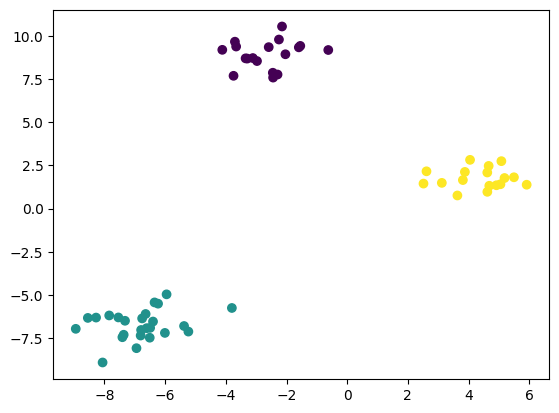

In [14]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)

In [15]:
# knee locator
!pip install kneed

In [16]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11),wcss, curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [17]:
from sklearn.metrics import silhouette_score
# score = silhouette_score(X_test,y_test_label)
# print(score)

In [18]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [19]:
silhouette_coefficients

[0.8452212918019965,
 0.8452212918019965,
 0.8452212918019965,
 0.8452212918019965,
 0.8452212918019965,
 0.8452212918019965,
 0.8452212918019965,
 0.8452212918019965,
 0.8452212918019965]

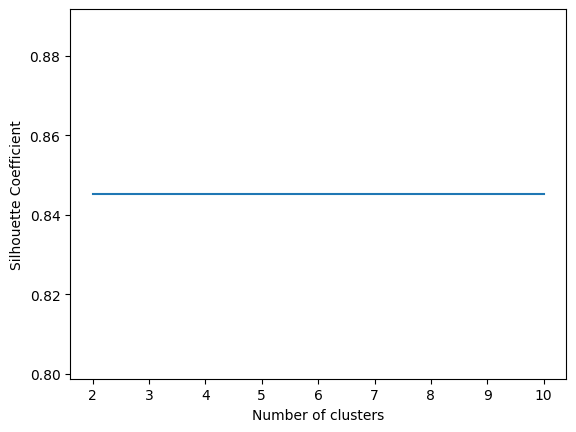

In [20]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()